In [1]:
%%capture
%pip install qldpc
%pip install matplotlib

## Quantum memory with circuit-level noise

Consider using a quantum error-correcting code as a quantum memory, and consider running a (noisy) circuit for one error correction cycle.  The logical error rate of the quantum memory is the probability which an error correction cycle induces a logical error.  For a fixed noise model, this logical error rate is a joint property of (a) the code, (b) the decoder, and (c) the syndrome measurement strategy used for error correction.

More specifically, consider small-scale memory experiments for the toric and surface codes:

- Build codes with code distance `d`.
- For each code, compile circuit a one logical QEC cycle (which consists of `d` rounds of syndrome measurement).
- Inject i.i.d. depolarizing noise with strength `p` after every gate in the circuit.
- Simulate and decode using `sinter`.
- Sweep over `(d, p)` and estimate logical error rates of both X-type and Z-type logical operators.

Physical experiments with one code block can only estimate the logical error rate of one type of logical operator, X or Z.  These experiments start in an eigenstate of the X or Z stabilizers and logicals, as appropriate, run one logical QEC cycle, and check whether circuit errors have caused logical operators to flip at the end.

The core feature in this demonstration is the `qldpc.circuits.get_memory_experiment` method, which constructs a circuit for a noisy memory experiment.  Below, we provide a function that collects these circuits into tasks that are handed over to `sinter` for simulating and estimating the error rates of logical observables.

### imports, simulation, and plotting code

In [2]:
import os
from collections.abc import Sequence

import matplotlib.pyplot as plt
import numpy as np
import sinter

from qldpc import circuits, codes, decoders
from qldpc.objects import Pauli, PauliXZ

from common import get_label

%matplotlib inline

In [3]:
def run_memory_experiments(
    codes_to_simulate: Sequence[codes.ClassicalCode | codes.CSSCode],
    basis: PauliXZ,
    error_rates: Sequence[float] = list(np.logspace(-3, -2, 5)),
    max_shots: int = 10**5,
    max_errors: int = 100,
    distance_trials: int = 100,
    **decoding_kwargs: object,
) -> list[sinter.TaskStats]:
    """Use sinter to simulate memory cycles of the given codes.

    This function ...
      1. Builds a memory experiment for each code.
      2. Adds a depolarizing noise to all gates, at the provided error rates.
      2. Wraps each noisy circuit in a `sinter.Task``.
      3. Runs batched Monte Carlo sampling with `sinter.collect`.

    Args:
        codes_to_simulate: The codes we wish to simulate.
        basis: The type of logical operator whose errors are tracked.
        error_rates: The i.i.d. probabilities of a depolarizing error after each gate.
        max_shots: Stop sampling the circuit after this many shots.
        max_errors: Stops the sampling process after this many errors have been seen in samples
            taken from the circuit.
        distance_trials: If the code distance is not known, estimate it with this many trials.
            The estimated distance determines the number of rounds of syndrome measurement.
        **decoding_kwargs: Arguments to pass to the decoder.

    Returns:
        A `sinter` stats object aggregating shots, errors, and metadata for downstream plotting.
    """
    noise_models = {
        prob: circuits.DepolarizingNoiseModel(prob, include_idling_error=False)
        for prob in error_rates
    }

    tasks = []
    for code in codes_to_simulate:
        distance = code.get_distance(bound=distance_trials)
        circuit = circuits.get_memory_experiment(code, basis=basis, num_rounds=distance)
        for prob in error_rates:
            noisy_circuit = noise_models[prob].noisy_circuit(circuit)
            tasks.append(
                sinter.Task(
                    circuit=noisy_circuit,
                    json_metadata={"label": get_label(code), "prob": prob},
                )
            )

    decoder = decoders.SinterDecoder(**decoding_kwargs)
    return sinter.collect(
        num_workers=os.cpu_count() - 2,
        max_shots=max_shots,
        max_errors=max_errors,
        tasks=tasks,
        decoders=["custom"],
        custom_decoders={"custom": decoder},
    )


def make_memory_experiment_figures(
    codes_to_simulate: Sequence[codes.ClassicalCode | codes.CSSCode],
    error_rates: Sequence[float] = list(np.logspace(-3, -2, 5)),
    max_shots: int = 10**5,
    max_errors: int = 100,
    distance_trials: int = 100,
    figsize: tuple[int, int] = (8, 4),
    **decoding_kwargs: object,
) -> tuple[plt.Figure, plt.Axes]:
    """Use sinter to simulate memory cycles of the given codes, and plot the results.

    Args:
        codes_to_simulate: The codes we wish to simulate.
        error_rates: The i.i.d. probabilities of a depolarizing error after each gate.
        max_shots: Stop sampling the circuit after this many shots.
        max_errors: Stops the sampling process after this many errors have been seen in samples
            taken from the circuit.
        distance_trials: If the code distance is not known, estimate it with this many trials.
            The estimated distance determines the number of rounds of syndrome measurement.
        figsize: The size of the figure to produce.
        **decoding_kwargs: Arguments to pass to the decoder.

    Returns:
        The matplotlib.pyplot figure and axis.
    """
    # collect statistics for X and Z logicals (which are corrupted, respectively, by Z and X errors)
    stats_x = run_memory_experiments(
        codes_to_simulate,
        Pauli.X,
        error_rates,
        max_shots,
        max_errors,
        distance_trials,
        **decoding_kwargs,
    )
    stats_z = run_memory_experiments(
        codes_to_simulate,
        Pauli.Z,
        error_rates,
        max_shots,
        max_errors,
        distance_trials,
        **decoding_kwargs,
    )

    # plot the statistics collected above
    figure, axes = plt.subplots(1, 2, sharey=True, figsize=figsize)
    for axis, stats, basis in zip(axes, [stats_x, stats_z], ["X", "Z"]):
        sinter.plot_error_rate(
            ax=axis,
            stats=stats,
            x_func=lambda stats: stats.json_metadata["prob"],
            group_func=lambda stats: stats.json_metadata["label"],
        )
        axis.axline(
            (0, 0),
            slope=1,
            color="k",
            linestyle=":",
            label=r"$p_{\mathrm{log}}=p_{\mathrm{phys}}$",
        )
        axis.set_title(f"{basis} logicals")
        axis.set_xlabel("physical error rate")

    for axis in axes:
        axis.loglog()
        axis.grid(which="both")
    axes[1].legend()
    axes[0].set_ylabel("logical error rate")
    figure.tight_layout()

    return figure, axes

### Surface code

The surface code is decodable with minimum weight perfect matching (MWPM).

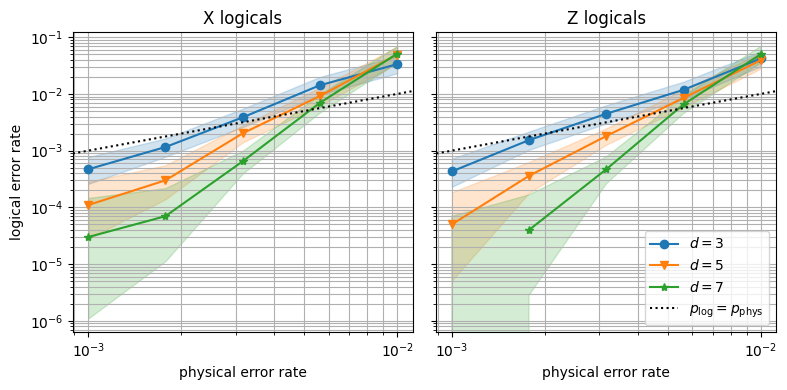

In [4]:
codes_to_simulate = [codes.SurfaceCode(dist, rotated=True) for dist in (3, 5, 7)]
make_memory_experiment_figures(codes_to_simulate, with_MWPM=True)
plt.show()

### Toric code

The toric code requires a different decoder.  We'll use BP-LSD.  These simulations may take a while.

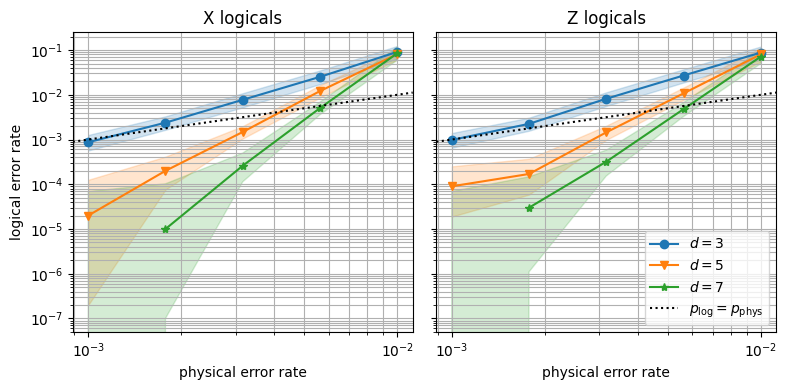

In [5]:
codes_to_simulate = [codes.ToricCode(dist, rotated=False) for dist in (3, 5, 7)]
decoding_kwargs = dict(
    with_BP_LSD=True, max_iter=30, bp_method="ms", lsd_method="lsd_cs", lsd_order=0
)
make_memory_experiment_figures(codes_to_simulate, **decoding_kwargs)
plt.show()